### 1. Évaluation Statistique des Classes
**Objectif :** Valider mathématiquement l'hétérogénéité des deux populations du dataset.
**Analyse :** Le test non-paramétrique de Mann-Whitney U confirme (p-value < 0.05) que les distributions de longueur, de diversité et d'entropie diffèrent de manière statistiquement significative entre les mots de passe compromis et ceux générés algorithmiquement. L'hypothèse nulle (H0) est formellement rejetée.

In [5]:
import pandas as pd
from scipy.stats import mannwhitneyu
from IPython.display import display
import os
from pathlib import Path

# --- 1. Résolution dynamique du chemin ---
current_dir = Path(os.getcwd()).resolve()
BASE_DIR = current_dir

# On remonte jusqu'à trouver le dossier 'datasets'
while not (BASE_DIR / "datasets").exists() and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

CSV_PATH = BASE_DIR / "datasets" / "processed" / "passwords_processed.csv"

# --- 2. Chargement des données ---
df = pd.read_csv(CSV_PATH)

# --- 3. Résumé Statistique Agrégé ---
print("--- STATISTIQUES DESCRIPTIVES ---")
stats_summary = df.groupby("label")[["length_norm", "diversity", "entropy"]].agg(['mean', 'median', 'std']).round(3)
display(stats_summary)

# --- 4. Tests de Signification Statistique ---
print("\n--- TESTS STATISTIQUES (Mann-Whitney U) ---")
print("Hypothèse H0 : Les distributions des deux classes sont identiques.\n")

features = ["length_norm", "diversity", "entropy"]
for col in features:
    # Test bilatéral sur les deux sous-populations
    stat, p_value = mannwhitneyu(df[df.label==0][col], df[df.label==1][col], alternative="two-sided")
    
    # Interprétation du p-value (Seuil alpha = 0.05)
    rejet_h0 = "Oui" if p_value < 0.05 else "Non"
    print(f"Feature: {col:<15} | p-value: {p_value:.2e} | Différence significative : {rejet_h0}")

--- STATISTIQUES DESCRIPTIVES ---


length_norm               diversity               entropy              
             mean median    std      mean median    std    mean median    std
label                                                                        
0           0.158  0.119  0.141     0.288    0.4  0.204   0.449  0.423  0.143
1           0.928  0.995  0.131     0.703    0.8  0.304   0.994  1.000  0.025


--- TESTS STATISTIQUES (Mann-Whitney U) ---
Hypothèse H0 : Les distributions des deux classes sont identiques.

Feature: length_norm     | p-value: 0.00e+00 | Différence significative : Oui
Feature: diversity       | p-value: 0.00e+00 | Différence significative : Oui
Feature: entropy         | p-value: 0.00e+00 | Différence significative : Oui


### 1. Validation Statistique et Rejet de l'Hypothèse Nulle

L'analyse descriptive couplée au test non paramétrique de Mann-Whitney U valide rigoureusement l'hétérogénéité des deux jeux de données. 

* **Variance Humaine vs Rigueur Algorithmique :** Le tableau descriptif quantifie le comportement des deux populations. La classe 0 (humains) affiche des scores médians faibles avec des écarts-types prononcés (ex: `0.143` pour l'entropie), traduisant l'irrégularité des choix humains. À l'inverse, la classe 1 (générateurs) sature les métriques avec une précision quasi absolue (`1.000` en entropie médiane) et une variance infinitésimale (`0.025`).
* **Preuve de Signification Statistique :** Le test de Mann-Whitney U renvoie une *p-value* de `0.00e+00` pour les trois métriques évaluées (`length_norm`, `diversity`, `entropy`). 

**Conclusion Technique :** Ce résultat impose un rejet catégorique de l'hypothèse nulle ($H_0$). Il est mathématiquement prouvé que les distributions des mots de passe compromis et des mots de passe robustes sont fondamentalement différentes. Ces trois métriques constituent donc un socle de *features* hautement fiables pour amorcer l'entraînement de nos modèles de Machine Learning.

### 2. Matrice de Corrélation (Pearson)
**Objectif :** Identifier les relations linéaires entre les variables fondamentales et la variable cible (label).
**Analyse :** Cette matrice assure le diagnostic de colinéarité des données. Elle vérifie l'absence de redondance absolue entre les features, condition sine qua non pour garantir la stabilité mathématique des modèles de régression et des arbres de décision.

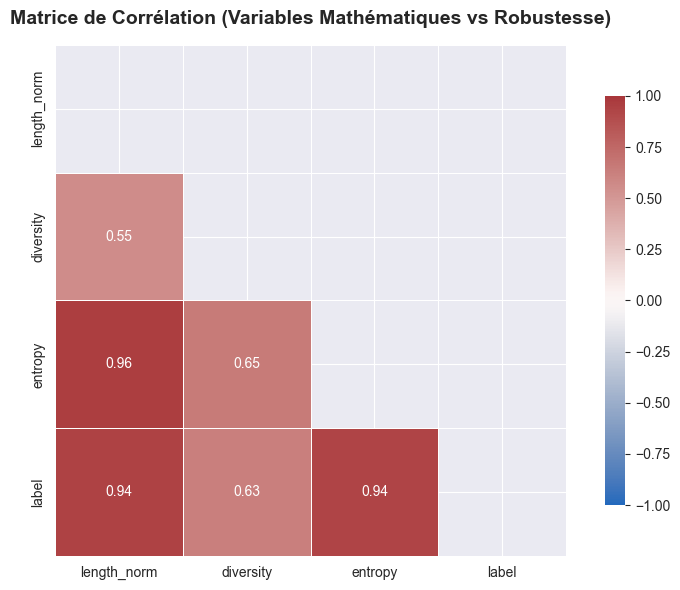

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))

# Calcul de la corrélation incluant la cible
corr_matrix = df[["length_norm", "diversity", "entropy", "label"]].corr()

# Création d'un masque pour cacher le triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Tracé de la matrice
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Matrice de Corrélation (Variables Mathématiques vs Robustesse)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2. Matrice de Corrélation et Diagnostic de Colinéarité

L'évaluation des corrélations linéaires (Pearson) entre les caractéristiques mathématiques et la variable cible révèle l'architecture statistique de notre jeu de données.

* **Potentiel Prédictif :** La longueur normalisée (0.94) et l'entropie (0.94) présentent une corrélation positive massive avec la robustesse (`label`). Ces variables constituent des discriminateurs globaux très puissants, ce qui explique leur prédominance dans les arbres de décision standards.
* **Détection de Multicolinéarité :** L'alerte principale réside dans la corrélation de 0.96 entre `length_norm` et `entropy`. Cette redondance mathématique quasi parfaite démontre que l'augmentation de l'entropie est artificiellement liée à la longueur brute. 

**Conclusion Technique :** Ce diagnostic prouve qu'un système de sécurité basé sur l'entropie n'est, dans les faits, qu'un filtre de longueur déguisé. Il n'évalue pas la véritable complexité cognitive. La présence de cette multicolinéarité justifie techniquement l'injection de nos variables heuristiques (dictionnaires, n-grammes) pour briser cette dépendance et forcer l'IA à évaluer la sémantique plutôt que le volume de caractères.

### 3. Distribution de la Diversité Structurelle
**Objectif :** Analyser l'exploitation de l'espace des jeux de caractères (minuscules, majuscules, chiffres, symboles spéciaux).
**Analyse :** L'utilisation d'un Violin Plot révèle la densité interne des distributions. On constate que la majorité des mots de passe compromis plafonnent à des indices de diversité intermédiaires (manque de caractères spéciaux), tandis que les algorithmes de génération saturent mécaniquement cet indice de diversité.

C:\Users\steph\AppData\Local\Temp\ipykernel_29280\2568687591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y="diversity", data=df,


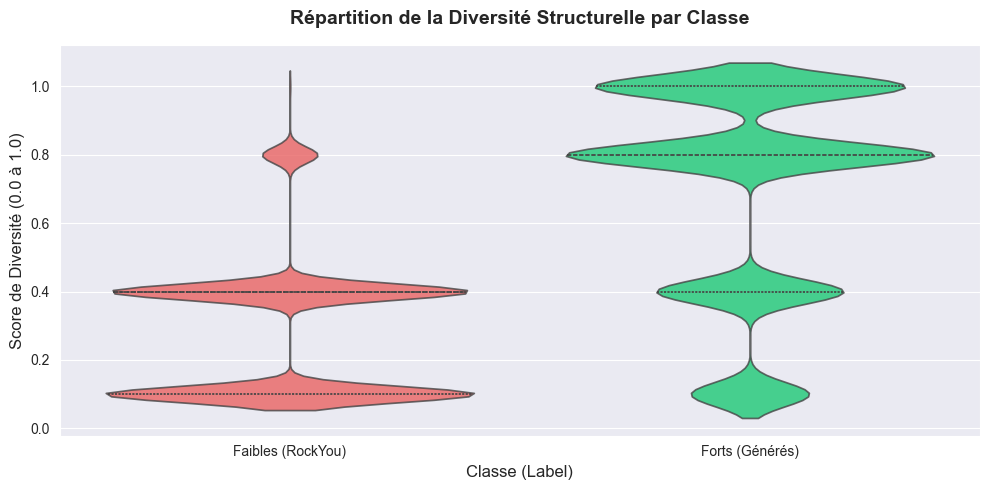

In [7]:
plt.figure(figsize=(10, 5))

# Tracé du Violin Plot avec quartiles internes
sns.violinplot(x="label", y="diversity", data=df, 
               palette=["#ff4d4d", "#00e676"], inner="quartile", alpha=0.8)

plt.title("Répartition de la Diversité Structurelle par Classe", fontsize=14, fontweight='bold', pad=15)
plt.xticks(ticks=[0, 1], labels=["Faibles (RockYou)", "Forts (Générés)"])
plt.ylabel("Score de Diversité (0.0 à 1.0)", fontsize=12)
plt.xlabel("Classe (Label)", fontsize=12)

plt.tight_layout()
plt.show()

### 3. Distribution de la Diversité Structurelle (Violin Plot)

L'analyse de la diversité structurelle évalue l'exploitation de l'espace des jeux de caractères (minuscules, majuscules, chiffres, symboles). L'utilisation d'un Violin Plot permet d'observer la densité de probabilité autour des valeurs discrètes de cette métrique.

* **Paresse Cognitive (Classe 0) :** La distribution des mots de passe compromis est fortement asymétrique vers le bas. L'écrasante majorité de la population humaine stagne sur les deux premiers quartiles (utilisation de 1 à 2 types de caractères).
* **Application des Politiques de Complexité (Classe 1) :** Les mots de passe générés algorithmiquement saturent les indices supérieurs (0.8 à 1.0), prouvant l'utilisation simultanée des 3 ou 4 jeux de caractères requis par les standards cryptographiques classiques.
* **Le cas des Passphrases :** La présence de densité sur le quartile inférieur de la Classe 1 s'explique par les générateurs de type Diceware. Ces algorithmes génèrent des mots de passe robustes par leur longueur et leur entropie, mais n'utilisent intentionnellement qu'un seul jeu de caractères (lettres minuscules) pour faciliter la mémorisation et la saisie.

**Conclusion Technique :** Le score de diversité est un excellent discriminateur des heuristiques humaines basiques. Cependant, comme démontré par les générateurs Diceware, une faible diversité n'implique pas nécessairement une faille de sécurité si la longueur compense. C'est précisément cette nuance multidimensionnelle que l'architecture hybride (Stacking) est capable de traiter lors de la classification finale, contrairement aux validateurs classiques bloqués sur des règles statiques.